## Races

In [1]:
import dash
from dash import dcc, html, Input, Output
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import approximation as approx

In [2]:
df_races = pd.read_csv("./archive/races.csv", index_col=0)
df_races = df_races.iloc[:, 0:6]
selected_years = [2010, 2015, 2019, 2020, 2023, 2025]
df_races = df_races[df_races["year"].isin(selected_years)]

df_races


,year,round,circuitId,name,date,time
raceId,,,,,,
337,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00
338,2010,2,1,Australian Grand Prix,2010-03-28,06:00:00
339,2010,3,2,Malaysian Grand Prix,2010-04-04,08:00:00
340,2010,4,17,Chinese Grand Prix,2010-04-18,06:00:00
341,2010,5,4,Spanish Grand Prix,2010-05-09,12:00:00
...,...,...,...,...,...,...
1164,2025,20,32,Mexico City Grand Prix,2025-11-02,20:00:00
1165,2025,21,18,São Paulo Grand Prix,2025-11-09,17:00:00
1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,06:00:00


### Circuits list

In [3]:
df_circuits = pd.read_csv("./archive/circuits.csv", index_col=0)
df_circuits = df_circuits.iloc[:, 1:-2]
df_circuits

,name,location,country,lat,lng
circuitId,,,,,
1,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800
2,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800
3,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060
4,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111
5,Istanbul Park,Istanbul,Turkey,40.95170,29.40500
...,...,...,...,...,...
75,Autódromo Internacional do Algarve,Portimão,Portugal,37.22700,-8.62670
76,Autodromo Internazionale del Mugello,Mugello,Italy,43.99750,11.37190
77,Jeddah Corniche Circuit,Jeddah,Saudi Arabia,21.63190,39.10440


## Merge circuits and races

In [4]:
df_general = pd.merge(df_races, df_circuits, how='inner', on='circuitId')
df_general['circuit'] = df_general['name_y']
df_general['name'] = df_general['name_x']
df_general = df_general.drop(columns={"name_x", "name_y", "round"}) #maybe year too?

sort_columns = ['name', 'circuit', 'location', 'country', 'date', 'lat', 'lng', 'circuitId', 'year'] 
df_general = df_general[sort_columns]
EU_COUNTRIES = {
    "Italy","France","Spain","Monaco","Austria","Hungary","Germany","Netherlands",
    "United Kingdom","Belgium","Portugal","San Marino","Switzerland"
}

df_general["region"] = df_general["country"].apply(lambda c: "EU" if c in EU_COUNTRIES else "Flyaway")
df_general



,name,circuit,location,country,date,lat,lng,circuitId,year,region
0,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,2010-03-14,26.03250,50.51060,3,2010,Flyaway
1,Australian Grand Prix,Albert Park Grand Prix Circuit,Melbourne,Australia,2010-03-28,-37.84970,144.96800,1,2010,Flyaway
2,Malaysian Grand Prix,Sepang International Circuit,Kuala Lumpur,Malaysia,2010-04-04,2.76083,101.73800,2,2010,Flyaway
3,Chinese Grand Prix,Shanghai International Circuit,Shanghai,China,2010-04-18,31.33890,121.22000,17,2010,Flyaway
4,Spanish Grand Prix,Circuit de Barcelona-Catalunya,Montmeló,Spain,2010-05-09,41.57000,2.26111,4,2010,EU
...,...,...,...,...,...,...,...,...,...,...
117,Mexico City Grand Prix,Autódromo Hermanos Rodríguez,Mexico City,Mexico,2025-11-02,19.40420,-99.09070,32,2025,Flyaway
118,São Paulo Grand Prix,Autódromo José Carlos Pace,São Paulo,Brazil,2025-11-09,-23.70360,-46.69970,18,2025,Flyaway
119,Las Vegas Grand Prix,Las Vegas Strip Street Circuit,Las Vegas,USA,2025-11-23,36.11470,-115.17300,80,2025,Flyaway
120,Qatar Grand Prix,Losail International Circuit,Al Daayen,Qatar,2025-11-30,25.49000,51.45420,78,2025,Flyaway


## 📝 Methodology – Estimating CO₂ Emissions for F1 Logistics (2010–2025)

The objective of this project is to visualize and optimize the environmental impact of Formula 1 logistics over multiple seasons (2010–2025).  
Since detailed freight data for each year is not publicly available, we built a simplified but realistic model based on official F1 Sustainability Reports, DHL communications, and typical aircraft/truck emission factors.

### ✈️ 1. Logistics Overview

- F1 logistics involve moving **~50 tons of cargo per team**, using up to **6–7 Boeing 747 cargo planes** for flyaway races, plus a large truck fleet for European events.  
- In a typical season, DHL estimates a **total distance of ~130,000 km** is covered by the circus.  
- Since 2023, DHL and F1 have introduced **Sustainable Aviation Fuel (SAF)** for flights and **100 % biofuel** for European truck transport, significantly reducing emissions.  
- F1 aims for **Net Zero emissions by 2030**.

---

### 🌍 2. Emission Factors

We estimated average emission factors (t CO₂ / 1000 km) for the **entire circus cargo** (not per team), separately for air and truck transport.  
Values were derived from typical aircraft/truck emission intensities multiplied by total F1 cargo weight, and adjusted over time according to the introduction of sustainable fuels.

| Year | Air factor (t CO₂ / 1000 km) | Truck factor (t CO₂ / 1000 km) | Motivation |
|------|-----------------------------|--------------------------------|------------|
| 2010 | 0.80 | 0.60 | Pre-SAF era, conventional trucking |
| 2015 | 0.75 | 0.50 | Efficiency improvements |
| 2019 | 0.70 | 0.45 | Newer fleets, some optimization |
| 2023 | 0.50 | 0.30 | Introduction of SAF and 100 % biofuel |
| 2025 | 0.40 | 0.25 | Projected Net Zero progress |

<br>

> ⚡ These are **aggregate factors** for the full F1 cargo operation, based on ~50 t cargo × 6 flights for flyaways, and truck convoys for European races.  
> Sources: DHL Sustainability Reports, F1 Sustainability Update, aircraft emission factors from ICAO, and truck emissions from EU standards.

---

### 🧮 3. Emission Calculation Formula

For each pair of consecutive races \( i \) and \( i+1 \), we calculate:

$$
\text{Distance}_{i,i+1} = \text{haversine}(\text{lat}_i,\text{lng}_i,\text{lat}_{i+1},\text{lng}_{i+1})
$$

$$
\text{Emissions}_{i,i+1} =
\text{Distance}_{i,i+1} \times
\frac{\text{Factor}_{\text{mode, year}}}{1000} \times
50000_{kg}
$$

where:
- **mode** = `Air` if the destination race is outside Europe, `Truck` otherwise.  
- **Factor_mode,year** = emission factor from the table above for the selected year.  
- Emissions are expressed in **tonnes of CO₂ equivalent**.
- 50000 kg represents an indicative value provided by DHL for an F1 team

Total seasonal emissions are obtained by summing over all consecutive race pairs.

---

### 📌 4. Assumptions Summary

- All teams have comparable freight footprints (no per-team differentiation).  
- Emission factors are averaged across the entire circus.
- Distances are calculated as great-circle distances using the Haversine formula.
- The model excludes sea freight and personnel travel to focus on **cargo logistics**.

---

✅ This methodology provides a **transparent, reproducible, and realistic** way to estimate and visualize the carbon impact of F1 race calendars, even in the absence of granular logistics data.


In [ ]:
# ===================== EMISSION FACTORS =====================
emission_factors = pd.DataFrame([
    {"year": 2010, "air_factor": 0.8, "truck_factor": 0.6},
    {"year": 2016, "air_factor": 0.8, "truck_factor": 0.08450},
    {"year": 2017, "air_factor": 0.75, "truck_factor": 0.08412 },
    {"year": 2018, "air_factor": 0.75, "truck_factor": 0.08231 },
    {"year": 2019, "air_factor": 0.7, "truck_factor": 0.08020},
    {"year": 2020, "air_factor": 0.7, "truck_factor": 0.07938 },
    {"year": 2021, "air_factor": 0.7, "truck_factor": 0.07895 },
    {"year": 2022, "air_factor": 0.7, "truck_factor": 0.07890 },
    {"year": 2023, "air_factor": 0.5, "truck_factor": 0.07294 },
    {"year": 2024, "air_factor": 0.5, "truck_factor": 0.07321},
    {"year": 2025, "air_factor": 0.4, "truck_factor": 0.07576},
])

emission_factors

,year,air_factor,truck_factor
0,2010,0.80,0.60
1,2015,0.75,0.50
2,2019,0.70,0.45
3,2020,0.70,0.45
4,2023,0.50,0.30
5,2025,0.40,0.25


In [6]:
# --- funzione haversine ---
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

In [7]:
def total_distance_and_emissions(df_path, year):
    factors = emission_factors.loc[emission_factors["year"] == year].iloc[0]

    total_dist = 0
    total_emissions = 0

    for i in range(len(df_path)-1):
        lon1, lat1 = df_path.iloc[i][["lng","lat"]]
        lon2, lat2 = df_path.iloc[i+1][["lng","lat"]]
        dist = haversine(lon1, lat1, lon2, lat2)
        total_dist += dist

        region = df_path.iloc[i+1]["region"]
        if region == "EU":
            emission_factor = factors["truck_factor"]
        else:
            emission_factor = factors["air_factor"]

        total_emissions += dist * (emission_factor / 1000) * 50_000  # 50.000 kg per 1000 km → da DHL

    return total_dist, total_emissions


In [8]:
# ===================== DATA =====================
df = df_general.copy().reset_index(drop=True)

# Make sure that date is a datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df

,name,circuit,location,country,date,lat,lng,circuitId,year,region
0,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,2010-03-14,26.03250,50.51060,3,2010,Flyaway
1,Australian Grand Prix,Albert Park Grand Prix Circuit,Melbourne,Australia,2010-03-28,-37.84970,144.96800,1,2010,Flyaway
2,Malaysian Grand Prix,Sepang International Circuit,Kuala Lumpur,Malaysia,2010-04-04,2.76083,101.73800,2,2010,Flyaway
3,Chinese Grand Prix,Shanghai International Circuit,Shanghai,China,2010-04-18,31.33890,121.22000,17,2010,Flyaway
4,Spanish Grand Prix,Circuit de Barcelona-Catalunya,Montmeló,Spain,2010-05-09,41.57000,2.26111,4,2010,EU
...,...,...,...,...,...,...,...,...,...,...
117,Mexico City Grand Prix,Autódromo Hermanos Rodríguez,Mexico City,Mexico,2025-11-02,19.40420,-99.09070,32,2025,Flyaway
118,São Paulo Grand Prix,Autódromo José Carlos Pace,São Paulo,Brazil,2025-11-09,-23.70360,-46.69970,18,2025,Flyaway
119,Las Vegas Grand Prix,Las Vegas Strip Street Circuit,Las Vegas,USA,2025-11-23,36.11470,-115.17300,80,2025,Flyaway
120,Qatar Grand Prix,Losail International Circuit,Al Daayen,Qatar,2025-11-30,25.49000,51.45420,78,2025,Flyaway


In [9]:
# --- TRAVELING SALESMAN PROBLEM --> OPTIMIZATION
def optimize_calendar(df_year):
    n = len(df_year)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                dist_matrix[i, j] = haversine(
                    df_year.loc[i, "lng"], df_year.loc[i, "lat"],
                    df_year.loc[j, "lng"], df_year.loc[j, "lat"]
                )
                
    G = nx.complete_graph(n)
    for i in range(n):
        for j in range(n):
            if i != j:
                G[i][j]["weight"] = dist_matrix[i, j]

    # TSP solution
    tsp_path = approx.traveling_salesman_problem(G, cycle=False, weight="weight")
    df_opt = df_year.iloc[tsp_path].reset_index(drop=True)
    return df_opt


In [10]:
# ===================== DASH APP =====================
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("F1 Travel Optimization Dashboard"),

    html.Div([
        html.Label("Select Calendar:"),
        dcc.Dropdown(
            id="calendar-choice",
            options=[
                {"label": "Real Calendar", "value": "real"},
                {"label": "Optimized Calendar (TSP)", "value": "opt"}
            ],
            value="real"
        )
    ], style={"width": "40%", "margin": "10px"}),

    html.Div([
        html.Label("Select Year:"),
        dcc.Slider(
            id="year-slider",
            min=df["year"].min(),
            max=df["year"].max(),
            step=1,
            value=df["year"].min(),
            marks={str(y): str(y) for y in sorted(df["year"].unique())}
        )
    ], style={"width": "80%", "margin": "20px"}),

    dcc.Graph(id="map-plot"),
        html.Div([
            dcc.Graph(id="distance-bar"),
            dcc.Graph(id="co2-bar")
        ], style={"display": "flex", "justifyContent": "space-around"})
    ])


@app.callback(
    [Output("map-plot", "figure"),
     Output("distance-bar", "figure"),
     Output("co2-bar", "figure")],
    [Input("calendar-choice", "value"),
     Input("year-slider", "value")]
)
def update_graphs(choice, year):
    df_year = df[df["year"] == year].reset_index(drop=True)

    df_real = df_year.sort_values("date").reset_index(drop=True)
    dist_real, co2_real = total_distance_and_emissions(df_real, year)

    df_opt = optimize_calendar(df_year)
    dist_opt, co2_opt = total_distance_and_emissions(df_opt, year)

    if choice == "real":
        df_path = df_real
        dist, co2 = dist_real, co2_real
        title = f"Real F1 Calendar {year}"
        color = "blue"
    else:
        df_path = df_opt
        dist, co2 = dist_opt, co2_opt
        title = f"Optimized F1 Calendar {year}"
        color = "red"

    # --- MAP ---
    fig_map = go.Figure()
    fig_map.add_trace(go.Scattergeo(
        lon=df_path["lng"],
        lat=df_path["lat"],
        text=df_path["name"] + " (" + df_path["circuit"] + ")",
        mode="markers+lines",
        marker=dict(size=8, color=color),
        line=dict(width=2, color=color),
        name=title
    ))
    fig_map.update_geos(
        projection_type="natural earth",
        showcountries=True, showland=True, landcolor="lightgray"
    )
    fig_map.update_layout(title=title + f" – {dist:.0f} km, {co2:.0f} kg CO₂")

    # --- DISTANCE BAR ---
    distance_fig = go.Figure(data=[
        go.Bar(name="Real", x=["Distance (km)"], y=[dist_real], marker_color="blue"),
        go.Bar(name="Optimized", x=["Distance (km)"], y=[dist_opt], marker_color="red")
    ])
    distance_fig.update_layout(
        barmode="group",
        title=f"Distance Comparison {year}",
        yaxis_title="Distance (km)"
    )

    # --- CO2 BAR ---
    co2_fig = go.Figure(data=[
        go.Bar(name="Real", x=["CO₂ (kg)"], y=[co2_real], marker_color="blue"),
        go.Bar(name="Optimized", x=["CO₂ (kg)"], y=[co2_opt], marker_color="red")
    ])
    co2_fig.update_layout(
        barmode="group",
        title=f"CO₂ Emissions Comparison {year}",
        yaxis_title="CO₂ (kg)"
    )

    return fig_map, distance_fig, co2_fig


if __name__ == "__main__":
    app.run(debug=True, port=8005)


In [10]:
import numpy as np
import pandas as pd

emission_factors = pd.DataFrame([
    {"year": 2016, "air_factor": 0.8, "truck_factor": 0.08450},
    {"year": 2017, "air_factor": 0.75, "truck_factor": 0.08412 },
    {"year": 2018, "air_factor": 0.75, "truck_factor": 0.08231 },
    {"year": 2019, "air_factor": 0.7, "truck_factor": 0.08020},
    {"year": 2020, "air_factor": 0.7, "truck_factor": 0.07938 },
    {"year": 2021, "air_factor": 0.7, "truck_factor": 0.07895 },
    {"year": 2022, "air_factor": 0.7, "truck_factor": 0.07890 },
    {"year": 2023, "air_factor": 0.5, "truck_factor": 0.07294 },
    {"year": 2024, "air_factor": 0.5, "truck_factor": 0.07321},
    {"year": 2025, "air_factor": 0.4, "truck_factor": 0.07576},
])

years_full = np.arange(2000, 2026)

# ===== LINEAR REGRESSION =====
years = emission_factors['year'].values
truck = emission_factors['truck_factor'].values

coeff_truck_lin_all = np.polyfit(years, truck, 1)

recent = emission_factors[emission_factors['year'] >= 2016]
coeff_truck_lin_recent = np.polyfit(recent['year'].values, recent['truck_factor'].values, 1)

truck_lin_all = np.polyval(coeff_truck_lin_all, years_full)
truck_lin_recent = np.polyval(coeff_truck_lin_recent, years_full)

# ===== LOG-LINEAR REGRESSION =====
# log su valori > 0
log_truck = np.log(truck)

# fit lineare in log-space
coeff_truck_log = np.polyfit(years, log_truck, 1)

# previsione in scala log → esponenziale
truck_log = np.exp(np.polyval(coeff_truck_log, years_full))

# ===== OUTPUT =====
df_out = pd.DataFrame({
    "year": years_full,
    "truck_factor_linear_2016plus": truck_lin_recent,
    "truck_factor_log": truck_log
})

# Applica limiti minimi (niente valori negativi)
df_out[df_out < 0] = np.nan
df_out
# opzionale:
# df_out.to_csv("emission_factors_2000_2025_all_models.csv", index=False)


,year,truck_factor_linear_2016plus,truck_factor_log
0,2000,0.104647,0.109215
1,2001,0.103397,0.107499
2,2002,0.102148,0.105809
3,2003,0.100898,0.104146
4,2004,0.099648,0.102509
5,2005,0.098398,0.100898
6,2006,0.097148,0.099313
7,2007,0.095899,0.097752
8,2008,0.094649,0.096216
9,2009,0.093399,0.094703


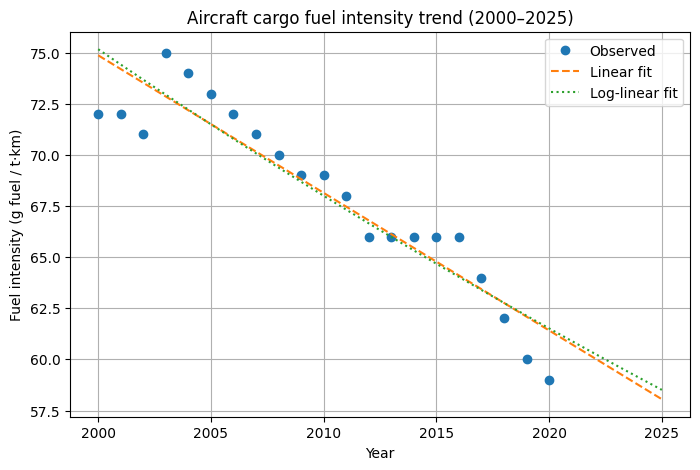

,year,fuel_g_tkm_linear,fuel_g_tkm_log,CO2_kg_tkm_linear,CO2_kg_tkm_log
0,2000,74.870130,75.168241,0.236590,0.237532
1,2001,74.197403,74.418694,0.234464,0.235163
2,2002,73.524675,73.676621,0.232338,0.232818
3,2003,72.851948,72.941948,0.230212,0.230497
4,2004,72.179221,72.214600,0.228086,0.228198
5,2005,71.506494,71.494505,0.225961,0.225923
6,2006,70.833766,70.781591,0.223835,0.223670
7,2007,70.161039,70.075786,0.221709,0.221439
8,2008,69.488312,69.377018,0.219583,0.219231
9,2009,68.815584,68.685219,0.217457,0.217045


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Dati osservati (ICCT - fuel burn trends) ===
data = pd.DataFrame([
    {"year": 2000, "fuel_g_tkm": 72},
    {"year": 2001, "fuel_g_tkm": 72},
    {"year": 2002, "fuel_g_tkm": 71},
    {"year": 2003, "fuel_g_tkm": 75},
    {"year": 2004, "fuel_g_tkm": 74},
    {"year": 2005, "fuel_g_tkm": 73},
    {"year": 2006, "fuel_g_tkm": 72},
    {"year": 2007, "fuel_g_tkm": 71},
    {"year": 2008, "fuel_g_tkm": 70},
    {"year": 2009, "fuel_g_tkm": 69},
    {"year": 2010, "fuel_g_tkm": 69},
    {"year": 2011, "fuel_g_tkm": 68},
    {"year": 2012, "fuel_g_tkm": 66},
    {"year": 2013, "fuel_g_tkm": 66},
    {"year": 2014, "fuel_g_tkm": 66},
    {"year": 2015, "fuel_g_tkm": 66},
    {"year": 2016, "fuel_g_tkm": 66},
    {"year": 2017, "fuel_g_tkm": 64},
    {"year": 2018, "fuel_g_tkm": 62},
    {"year": 2019, "fuel_g_tkm": 60},
    {"year": 2020, "fuel_g_tkm": 59},
])

# === 2. Conversione in kg CO₂ / (t·km) ===
# 1 g fuel = 0.001 kg fuel
# 1 kg fuel → 3.16 kg CO₂ (ICAO)
data["CO2_kg_tkm"] = (data["fuel_g_tkm"] / 1000) * 3.16

# === 3. Regressioni ===
years = data["year"].values
fuel_g = data["fuel_g_tkm"].values
co2 = data["CO2_kg_tkm"].values

years_full = np.arange(2000, 2026)

# --- Lineare ---
coef_lin = np.polyfit(years, fuel_g, 1)
fuel_pred_lin = np.polyval(coef_lin, years_full)

# --- Log-lineare (fit sull’andamento esponenziale) ---
coef_log = np.polyfit(years, np.log(fuel_g), 1)
fuel_pred_log = np.exp(np.polyval(coef_log, years_full))

# --- Conversione a kg CO₂ / (t·km) ---
co2_lin = (fuel_pred_lin / 1000) * 3.16
co2_log = (fuel_pred_log / 1000) * 3.16

# === 4. DataFrame finale ===
df_air_factors = pd.DataFrame({
    "year": years_full,
    "fuel_g_tkm_linear": fuel_pred_lin,
    "fuel_g_tkm_log": fuel_pred_log,
    "CO2_kg_tkm_linear": co2_lin,
    "CO2_kg_tkm_log": co2_log
})

# === 5. Clippiamo i valori negativi o troppo bassi (per sicurezza) ===
df_air_factors = df_air_factors.clip(lower=0)

# === 6. Visualizzazione ===
plt.figure(figsize=(8,5))
plt.plot(data["year"], data["fuel_g_tkm"], "o", label="Observed")
plt.plot(df_air_factors["year"], df_air_factors["fuel_g_tkm_linear"], label="Linear fit", linestyle="--")
plt.plot(df_air_factors["year"], df_air_factors["fuel_g_tkm_log"], label="Log-linear fit", linestyle=":")
plt.xlabel("Year")
plt.ylabel("Fuel intensity (g fuel / t·km)")
plt.title("Aircraft cargo fuel intensity trend (2000–2025)")
plt.legend()
plt.grid(True)
plt.show()

df_air_factors
